In [1]:
!pip install folium


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [89]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import folium
import seaborn as sns
from folium.plugins import HeatMap

In [90]:
conn = sqlite3.connect("usa_pollution.db") 

In [91]:
cursor = conn.cursor()

# Create locations table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS locations (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        state TEXT NOT NULL,
        county TEXT NOT NULL,
        city TEXT NOT NULL,
        latitude REAL NOT NULL,
        longitude REAL NOT NULL
    )
''')

In [5]:
# Create pollutants table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS pollutants (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        location INTEGER NOT NULL,
        year INTEGER NOT NULL,
        month INTEGER NOT NULL,
        day INTEGER NOT NULL,
        o3_mean REAL,
        o3_max_value REAL,
        o3_first_max_hour REAL,
        o3_aqi REAL,
        co_mean REAL,
        co_max_value REAL,
        co_first_max_hour REAL,
        co_aqi REAL,
        so2_mean REAL,
        so2_max_value REAL,
        so2_first_max_hour REAL,
        so2_aqi REAL,
        no2_mean REAL,
        no2_max_value REAL,
        no2_first_max_hour REAL,
        no2_aqi REAL,
        FOREIGN KEY(location) REFERENCES locations(id)
    )
''')

In [92]:
conn.commit()

In [93]:
query = "SELECT * FROM locations;"
df1_sql = pd.read_sql_query(query, conn)

# Check column names
print(df_sql.columns)

Index(['id', 'state', 'county', 'city', 'latitude', 'longitude'], dtype='object')


In [94]:
query = "SELECT * FROM pollutants;"
df_sql = pd.read_sql_query(query, conn)

# Check column names
print(df_sql.columns)

Index(['id', 'location', 'year', 'month', 'day', 'o3_mean', 'o3_max_value',
       'o3_first_max_hour', 'o3_aqi', 'co_mean', 'co_max_value',
       'co_first_max_hour', 'co_aqi', 'so2_mean', 'so2_max_value',
       'so2_first_max_hour', 'so2_aqi', 'no2_mean', 'no2_max_value',
       'no2_first_max_hour', 'no2_aqi'],
      dtype='object')


In [95]:
# Filter the data for years between 2013 and 2023
df_sql['year'] = df_sql['year'].astype(int)  # Ensure year column is integer
df_filtered = df_sql[(df_sql['year'] >= 2013) & (df_sql['year'] <= 2023)]

# Group by state and compute mean AQI values for each pollutant
mean_aqi = df_filtered.groupby('location')[['o3_aqi', 'co_aqi', 'so2_aqi', 'no2_aqi']].mean().reset_index()

# Set index as state for visualization
mean_aqi.set_index('location', inplace=True)

In [9]:
# Dictionary to map FIPS codes to state names
fips_to_state = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
    8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 12: 'Florida', 13: 'Georgia',
    15: 'Hawaii', 16: 'Idaho', 17: 'Illinois', 18: 'Indiana', 19: 'Iowa', 20: 'Kansas',
    21: 'Kentucky', 22: 'Louisiana', 23: 'Maine', 24: 'Maryland', 25: 'Massachusetts',
    26: 'Michigan', 27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey', 35: 'New Mexico',
    36: 'New York', 37: 'North Carolina', 38: 'North Dakota', 39: 'Ohio', 40: 'Oklahoma',
    41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island', 45: 'South Carolina',
    46: 'South Dakota', 47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont',
    51: 'Virginia', 53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming'
}

# Convert location codes to state names
df_sql['location'] = df_sql['location'].map(fips_to_state)

In [96]:
print(df_sql[['location']].drop_duplicates())  # Check unique location values
print(df_sql.dtypes)

        location
0              1
348            2
533            3
880            4
1243           5
...          ...
445983       148
480818       149
551861       150
563831       151
595944       152

[152 rows x 1 columns]
id                      int64
location                int64
year                    int64
month                   int64
day                     int64
o3_mean               float64
o3_max_value          float64
o3_first_max_hour     float64
o3_aqi                float64
co_mean               float64
co_max_value          float64
co_first_max_hour     float64
co_aqi                float64
so2_mean              float64
so2_max_value         float64
so2_first_max_hour    float64
so2_aqi               float64
no2_mean              float64
no2_max_value         float64
no2_first_max_hour    float64
no2_aqi               float64
dtype: object


In [97]:
# Count missing values
missing_states = df_sql['location'].isna().sum()
print(f"Number of missing state values: {missing_states}")

# Drop rows with missing state values (if few)
df_sql = df_sql.dropna(subset=['location'])

# OR (if you suspect errors in data entry, fill them manually)
df_sql['location'] = df_sql['location'].fillna('Unknown')


Number of missing state values: 0


In [99]:
# SQL Query to fetch pollution data with latitude & longitude
query = """
SELECT l.latitude, l.longitude, p.o3_aqi
FROM pollutants p
JOIN locations l ON p.location = l.id
WHERE p.o3_aqi IS NOT NULL;
"""

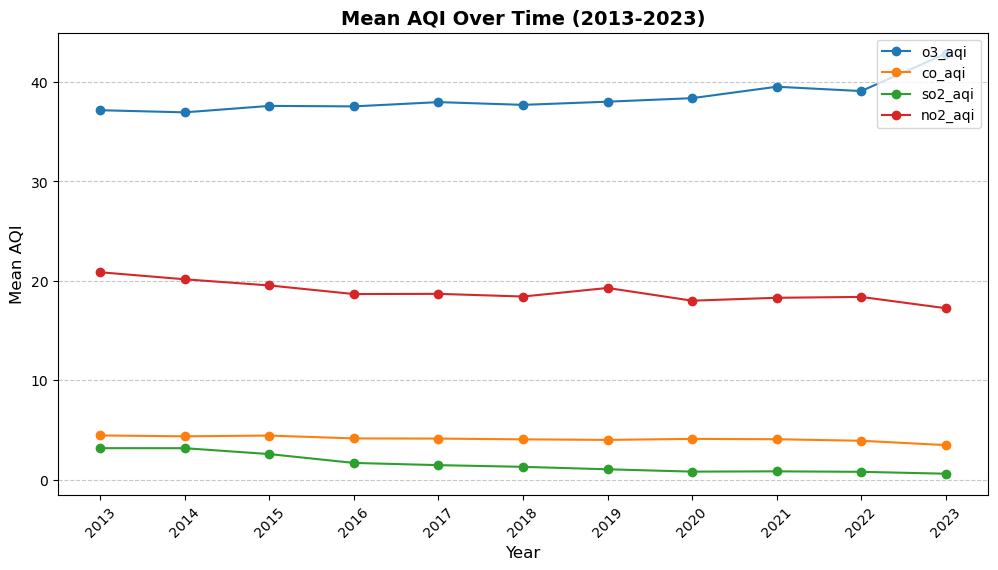

In [120]:
import matplotlib.pyplot as plt
df_filtered = df_sql[(df_sql["year"] >= 2013) & (df_sql["year"] <= 2023)]

# Group by year and calculate mean AQI for each pollutant per year
df_yearly = df_filtered.groupby(['year'])[['o3_aqi', 'co_aqi', 'so2_aqi', 'no2_aqi']].mean().reset_index()

# Plot AQI trends over time
plt.figure(figsize=(12, 6))

for pollutant in ['o3_aqi', 'co_aqi', 'so2_aqi', 'no2_aqi']:
    plt.plot(df_yearly['year'], df_yearly[pollutant], marker='o', label=pollutant)

plt.title('Mean AQI Over Time (2013-2023)', fontsize=14, fontweight="bold")
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean AQI', fontsize=12)
plt.xticks(df_yearly['year'], rotation=45)  # Ensure all years are visible
plt.legend(title='Pollutants')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc="upper right")

# Save the figure
plt.savefig("Mean_aqi_year.png")
plt.show()


In [ ]:
#standard deviation on AQI level fluctuation to show state with highest ozone AQI fluctuation between 2013 to 2023

In [101]:
#Step:1
df_sql['year'] = pd.to_numeric(df_sql['year'], errors='coerce')  

# Filter for years between 2013 and 2023
df_filtered = df_sql[(df_sql['year'] >= 2013) & (df_sql['year'] <= 2023)]

# Check the filtered data
print(df_filtered.head())

            id  location  year  month  day   o3_mean  o3_max_value  \
310236  310237       137  2013     12    1  0.014176         0.026   
310237  310238       137  2013     12    2  0.008706         0.012   
310238  310239       137  2013     12    3  0.008059         0.012   
310239  310240       137  2013     12    4  0.011118         0.014   
310240  310241       137  2013     12    5  0.011176         0.014   

        o3_first_max_hour  o3_aqi   co_mean  ...  co_first_max_hour  co_aqi  \
310236                9.0    24.0  0.266667  ...                0.0     6.0   
310237               20.0    11.0  0.400000  ...                0.0     6.0   
310238               22.0    11.0  0.258333  ...                0.0     3.0   
310239                8.0    13.0  0.116667  ...               20.0     2.0   
310240               18.0    13.0  0.108333  ...               19.0     2.0   

        so2_mean  so2_max_value  so2_first_max_hour  so2_aqi   no2_mean  \
310236  0.313636            1

In [102]:
#Step-2 Mena and standard deviation for  o3 AQI pollutant yeach year from 2013-2023 for top 5 state 

import pandas as pd

# Group by 'location' and 'year' to calculate the mean and standard deviation for each year
mean_o3_by_year = df_filtered.groupby(['location', 'year'])['o3_aqi'].mean().reset_index()
fluctuations_o3_by_year = df_filtered.groupby(['location', 'year'])['o3_aqi'].std().reset_index()

# Rename the columns for clarity
mean_o3_by_year.columns = ['location', 'year', 'o3_aqi_mean']
fluctuations_o3_by_year.columns = ['location', 'year', 'o3_aqi_fluctuation']

# Merge the mean and fluctuation data
o3_stats_by_year = pd.merge(mean_o3_by_year, fluctuations_o3_by_year, on=['location', 'year'])

# To get the state with the highest fluctuation in O3 AQI over the entire period (2013-2023),
# We calculate the total standard deviation across all years for each state
state_fluctuation = o3_stats_by_year.groupby('location')['o3_aqi_fluctuation'].std().reset_index()

# Calculate the mean Ozone AQI for each state over the entire period (2013-2023)
state_mean_o3 = o3_stats_by_year.groupby('location')['o3_aqi_mean'].mean().reset_index()

# Merge the state fluctuation and mean Ozone AQI data
state_fluctuation_mean = pd.merge(state_fluctuation, state_mean_o3, on='location')

# Sort by highest fluctuation
state_fluctuation_mean_sorted = state_fluctuation_mean.sort_values(by='o3_aqi_fluctuation', ascending=False)

# Check the results
print(state_fluctuation_mean_sorted.head(10))  # Top 10 states with the highest fluctuation in O3 AQI and their mean values


    location  o3_aqi_fluctuation  o3_aqi_mean
45        90            8.580099    49.245109
57       107            8.026011    42.966376
30        59            6.307598    38.196810
95       149            6.057391    46.464347
55       105            5.941454    41.377783
67       119            5.666019    38.307598
81       134            5.493333    41.984224
10        15            5.403356    61.983166
32        61            4.877718    33.189346
22        38            4.865564    36.663275


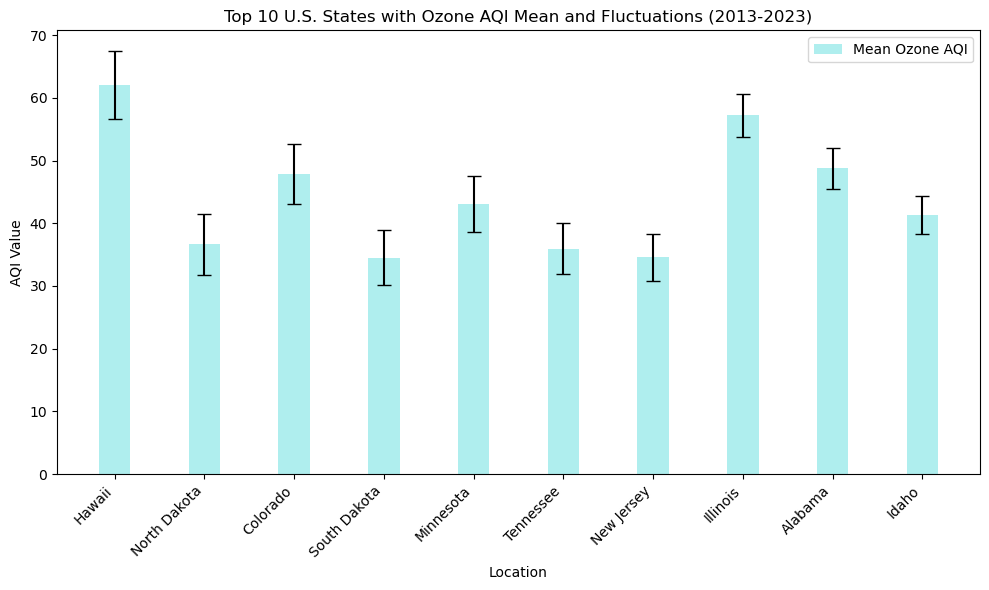

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Data for visualization (updated table)
data = {
    'location': ['Hawaii', 'North Dakota', 'Colorado', 'South Dakota', 'Minnesota', 'Tennessee', 
                 'New Jersey', 'Illinois', 'Alabama', 'Idaho'],
    'o3_aqi_mean': [61.983166, 36.663275, 47.830524, 34.503564, 43.062610, 35.961069, 
                    34.586929, 57.197172, 48.775820, 41.306625],
    'o3_aqi_fluctuation': [5.403356, 4.865564, 4.811250, 4.419769, 4.392462, 4.003478, 
                           3.779420, 3.384186, 3.260475, 2.979574]
}

# Create DataFrame
import pandas as pd
df = pd.DataFrame(data)

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Set the locations for the x-axis
locations = df['location']

# Bar chart for mean AQI and fluctuation with error bars
bar_width = 0.35
index = np.arange(len(locations))

# Plot bars for mean AQI (Ozone)
bars = ax.bar(index, df['o3_aqi_mean'], bar_width, label='Mean Ozone AQI', 
              color='#AFEEEE', yerr=df['o3_aqi_fluctuation'], capsize=5)

# Add labels and title
ax.set_xlabel('Location')
ax.set_ylabel('AQI Value')
ax.set_title('Top 10 U.S. States with Ozone AQI Mean and Fluctuations (2013-2023)')
ax.set_xticks(index)
ax.set_xticklabels(locations, rotation=45, ha='right')

# Add a legend
ax.legend()

# Display the plot
plt.tight_layout()
# Save the figure before displaying it
plt.savefig("tope state_o3_aqi.png", dpi=300, bbox_inches='tight')
plt.show()

In [116]:
# Read locations table
query = "SELECT * FROM locations;"
df_locations = pd.read_sql_query(query, conn)

# Read pollutants table (filtering only years 2013-2023)
query = "SELECT * FROM pollutants WHERE year BETWEEN 2013 AND 2023;"
df_pollutants = pd.read_sql_query(query, conn)

# Merge the two tables based on location ID
df_merged = df_pollutants.merge(df_locations, left_on='location', right_on='id', how='left')


In [117]:
# Group by city and calculate mean O3 AQI
o3_stats_by_city = df_merged.groupby('city')['o3_aqi'].mean().reset_index()

# Sort by highest and lowest O3 AQI
top_cities = o3_stats_by_city.sort_values(by='o3_aqi', ascending=False).head(10)  # Highest AQI
bottom_cities = o3_stats_by_city.sort_values(by='o3_aqi', ascending=True).head(10)  # Lowest AQI

# Display results
print("Top 10 Cities with Highest O3 AQI (2013-2023):")
print(top_cities)

print("\nTop 10 Cities with Lowest O3 AQI (2013-2023):")
print(bottom_cities)

Top 10 Cities with Highest O3 AQI (2013-2023):
           city     o3_aqi
74     Rubidoux  62.549819
42      Fontana  62.337801
89  Victorville  57.214419
57      Memphis  54.346341
43       Fresno  51.658391
12     Calexico  48.660882
67      Phoenix  48.457463
11      Burbank  48.166667
58      Midvale  45.918216
0   Albuquerque  45.300027

Top 10 Cities with Lowest O3 AQI (2013-2023):
            city     o3_aqi
41     Fairbanks  19.052111
17   Cherry Tree  23.500000
27         Davie  24.573770
40        Eureka  24.655018
64       Oakland  25.099546
80       Seattle  26.538492
52        Lompoc  27.460882
69      Portland  29.209085
78     San Pablo  29.225370
70  Presque Isle  29.902816


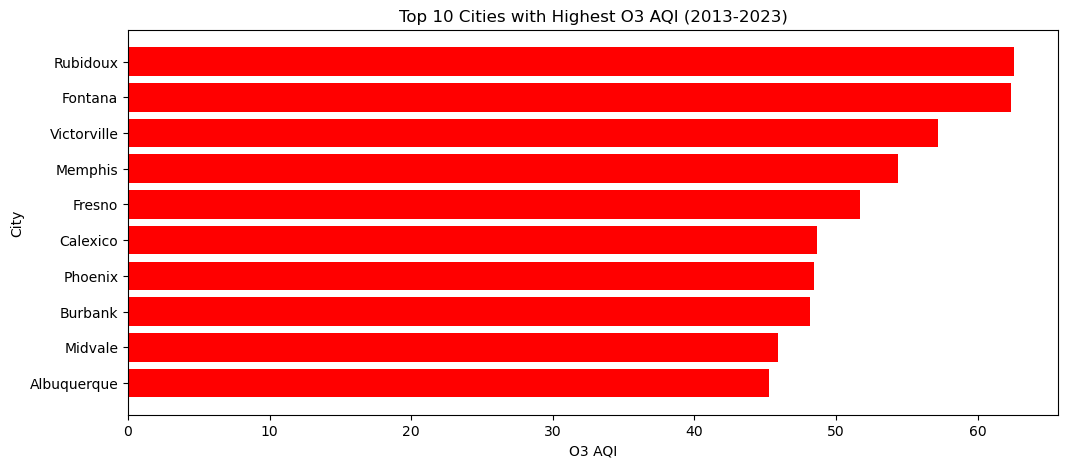

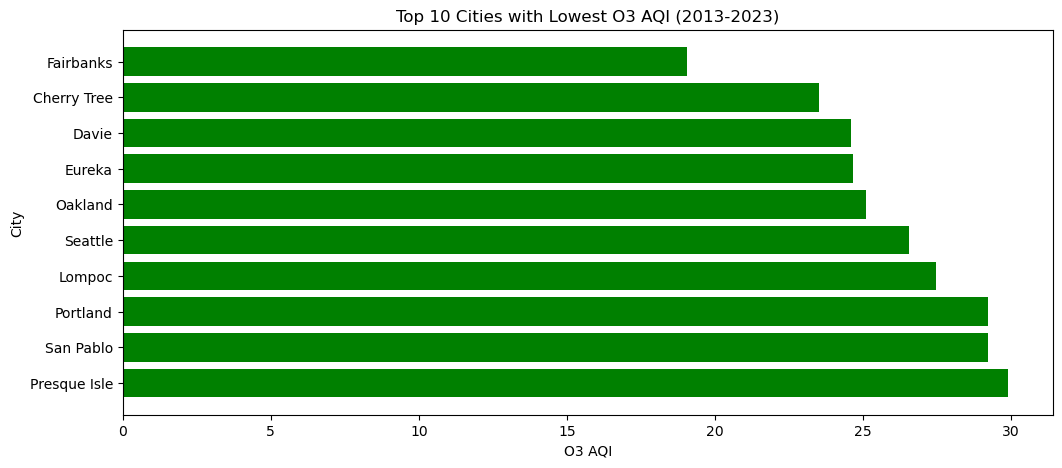

In [130]:
# Plot highest O3 AQI cities
plt.figure(figsize=(12, 5))
plt.barh(top_cities['city'], top_cities['o3_aqi'], color='red')
plt.xlabel("O3 AQI")
plt.ylabel("City")
plt.title("Top 10 Cities with Highest O3 AQI (2013-2023)")
plt.gca().invert_yaxis()  

# Save the figure before displaying it
plt.savefig("tope high state_o3_aqi.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot lowest O3 AQI cities
plt.figure(figsize=(12, 5))
plt.barh(bottom_cities['city'], bottom_cities['o3_aqi'], color='green')
plt.xlabel("O3 AQI")
plt.ylabel("City")
plt.title("Top 10 Cities with Lowest O3 AQI (2013-2023)")
plt.gca().invert_yaxis()

# Save the figure before displaying it
plt.savefig("low cities_o3_aqi.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
conn.close()